In [1]:
# Cell 1: imports and load
import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
pd.set_option("display.max_colwidth", 200)
plt.rcParams["figure.figsize"] = (10, 5)

traces = [json.loads(line) for line in Path("../data/traces/pcmb_traces.jsonl").open()]
source = [json.loads(line) for line in Path("../data/raw/pcmb_500.jsonl").open()]

df = pd.DataFrame(traces)
src_df = pd.DataFrame(source)

print(f"Traces verified: {len(df)} / {len(src_df)} = {100*len(df)/len(src_df):.1f}%")

Traces verified: 413 / 500 = 82.6%


In [2]:
# Cell 2: which subjects had the lowest verification rates?
src_counts = src_df["subject"].value_counts()
trc_counts = df["subject"].value_counts()
rate = (trc_counts / src_counts * 100).round(1).rename("verify_rate_%")
summary = pd.concat([src_counts.rename("sourced"), trc_counts.rename("verified"), rate], axis=1)
print(summary)

# Math and physics typically have higher pass rates than chemistry/biology for R1.
# If one subject is much lower than others, look at the failed questions to understand why.

           sourced  verified  verify_rate_%
subject                                    
physics        125       107           85.6
chemistry      125       102           81.6
biology        125       110           88.0
math           125        94           75.2


In [3]:
# Cell 3: which questions failed?
failed_ids = set(src_df["id"]) - set(df["id"])
failed = src_df[src_df["id"].isin(failed_ids)]
print(f"{len(failed)} failed questions")
print(failed.groupby("subject").size())

# Read 3 failures from each subject — was it ambiguous? too hard? bad question?
for subject in ["physics", "chemistry", "biology", "math"]:
    fail_sub = failed[failed["subject"] == subject]
    if len(fail_sub) == 0:
        continue
    print(f"\n{'='*80}\n  {subject.upper()} FAILURES ({len(fail_sub)})\n{'='*80}")
    for _, row in fail_sub.head(3).iterrows():
        print(f"\n[{row['id']}] correct: {row['answer_letter']}")
        print(row["question"][:400])

87 failed questions
subject
biology      15
chemistry    23
math         31
physics      18
dtype: int64

  PHYSICS FAILURES (18)

[49e9b1f51efbb1d2] correct: E
An observer S who lives on the x-axis sees a flash of red light at x = 1210 m, then after 4.96 µs, a flash of blue at x = 480 m. Use subscripts R and B to label the coordinates of the events. What is the measured time interval (in µs) between these flashes?

[e339510fbb9d95c2] correct: J
As the explosive TNT burns, it releases about 4.2 x 106 joules/kg. The molecular weight of TNT is 227. Find the energy released by one molecule of TNT in the process. What is the fractional change in mass that occurs as one kg of TNT explodes?

[520e75961a83b0c9] correct: F
What is the cost of operating for 24 hr a lamp requiring1.0 amp on a 100-volt line if the cost of electric energy is $0.50/kw-hr?

  CHEMISTRY FAILURES (23)

[287ca787551b6256] correct: A
In one of the experiments on gravitational sedimentation equilibrium, the number ofgamb

       reasoning_tokens  reasoning_chars  reasoning_words
count             413.0            413.0            413.0
mean             1666.0           4828.0            843.0
std              2463.0           7694.0           1349.0
min               188.0            493.0            100.0
25%               452.0           1127.0            207.0
50%               767.0           2133.0            364.0
75%              1533.0           4232.0            736.0
max             15569.0          51366.0           9383.0


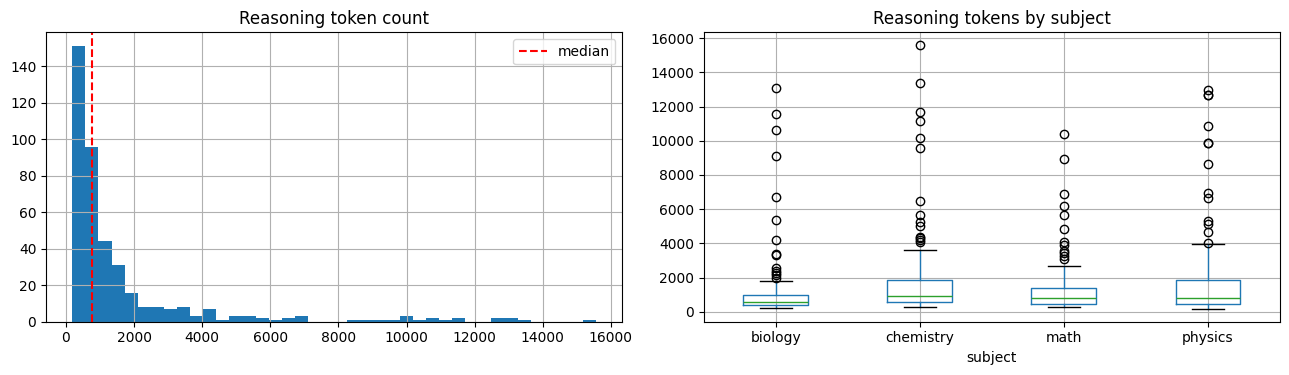

In [4]:
# Cell 4: reasoning length distribution
df["reasoning_chars"] = df["reasoning"].str.len()
df["reasoning_words"] = df["reasoning"].str.split().str.len()

print(df[["reasoning_tokens", "reasoning_chars", "reasoning_words"]].describe().round(0))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df["reasoning_tokens"].hist(bins=40, ax=axes[0])
axes[0].set_title("Reasoning token count")
axes[0].axvline(df["reasoning_tokens"].median(), color="red", linestyle="--", label="median")
axes[0].legend()

df.boxplot(column="reasoning_tokens", by="subject", ax=axes[1])
axes[1].set_title("Reasoning tokens by subject")
plt.suptitle("")
plt.tight_layout()
plt.show()

count      413.0
mean      1984.0
std       2500.0
min        403.0
25%        741.0
50%       1112.0
75%       1885.0
max      15943.0
Name: est_total_tokens, dtype: float64

95th percentile: 7178
99th percentile: 13086
Maximum:         15943


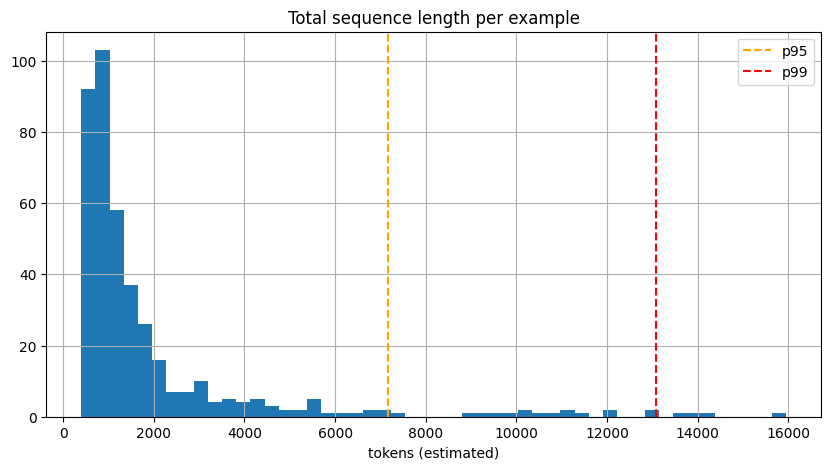


Suggested max_length for training: 13312
(captures 99% of examples; the remaining 1% will be truncated)


In [5]:
# Cell 5: max sequence length budget for training
# total tokens for SFT = prompt + reasoning + final answer
# rule of thumb: 1.3 tokens per word
df["est_total_tokens"] = (
    (df["question"].str.split().str.len() * 1.3)        # question
    + (df["options"].apply(lambda os: sum(len(o.split()) for o in os)) * 1.3)  # options
    + df["reasoning_tokens"]                             # reasoning
    + (df["answer_text"].str.split().str.len() * 1.3)    # final answer
    + 100                                                # boilerplate / chat template
)

print(df["est_total_tokens"].describe().round(0))
print(f"\n95th percentile: {df['est_total_tokens'].quantile(0.95):.0f}")
print(f"99th percentile: {df['est_total_tokens'].quantile(0.99):.0f}")
print(f"Maximum:         {df['est_total_tokens'].max():.0f}")

df["est_total_tokens"].hist(bins=50)
for q, c in [(0.95, "orange"), (0.99, "red")]:
    plt.axvline(df["est_total_tokens"].quantile(q), color=c, linestyle="--", label=f"p{int(q*100)}")
plt.title("Total sequence length per example")
plt.xlabel("tokens (estimated)")
plt.legend()
plt.show()

# Use p99 to choose your training max_length. Round up to nearest 1024.
import math
suggested_max_length = int(math.ceil(df["est_total_tokens"].quantile(0.99) / 1024) * 1024)
print(f"\nSuggested max_length for training: {suggested_max_length}")
print(f"(captures 99% of examples; the remaining 1% will be truncated)")

In [6]:
# Cell 6: read random short, median, and long traces — manual quality check
# This is where you eyeball the actual data. Spend 15 minutes here.
def read_trace(idx, max_chars=2000):
    t = df.iloc[idx]
    print("=" * 80)
    print(f"[{t['id']}] {t['subject']} — answer {t['answer_letter']} (predicted {t['predicted_letter']})")
    print("=" * 80)
    print(t["question"])
    print()
    print(f"--- reasoning ({t['reasoning_tokens']} tokens, showing first {max_chars} chars) ---")
    print(t["reasoning"][:max_chars])
    if len(t["reasoning"]) > max_chars:
        print(f"\n... [truncated; {len(t['reasoning']) - max_chars} more chars]")
    print()
    print(f"--- final answer text ---")
    print(t["answer_text"][:500])


# Shortest 2, median 2, longest 2
sorted_by_len = df["reasoning_tokens"].sort_values()
indices = (
    sorted_by_len.index[:2].tolist()              # shortest 2
    + sorted_by_len.index[len(df)//2 - 1 : len(df)//2 + 1].tolist()  # median
    + sorted_by_len.index[-2:].tolist()           # longest 2
)
for i in indices:
    read_trace(i)
    print("\n\n")

[10121bb1e19b6c3b] physics — answer D (predicted D)
When a spinning system contracts in the absence of an external torque its rotational speed increases and its angular momentum

--- reasoning (188 tokens, showing first 2000 chars) ---
We are asked: "When a spinning system contracts in the absence of an external torque its rotational speed increases and its angular momentum ..." Options A to J. We need to choose the correct statement about angular momentum. According to conservation of angular momentum, if no external torque acts, the angular momentum of a system remains constant. The rotational speed increases because moment of inertia decreases, so angular speed increases to keep angular momentum constant. So angular momentum remains unchanged. Thus answer is D. "remains unchanged". Let's ensure the question: "its rotational speed increases and its angular momentum" So the blank should be filled with what happens to angular momentum. So answer D.

--- final answer text ---
When no ex

In [7]:
# Cell 7: detect potential quality issues
# Heuristics, not perfect, but they catch real problems.

issues = []

# 1. Very short reasoning — under 200 tokens probably isn't real reasoning
short_reasoning = df[df["reasoning_tokens"] < 200]
if len(short_reasoning) > 0:
    issues.append(("very_short_reasoning", short_reasoning))

# 2. Very long reasoning — over 12K tokens might be repetition or struggle
very_long = df[df["reasoning_tokens"] > 12000]
if len(very_long) > 0:
    issues.append(("very_long_reasoning", very_long))

# 3. Answer text doesn't contain the predicted letter (parser edge case)
def answer_contains_letter(row):
    if not row["answer_text"] or not row["predicted_letter"]:
        return False
    return row["predicted_letter"].upper() in row["answer_text"].upper()
no_letter = df[~df.apply(answer_contains_letter, axis=1)]
if len(no_letter) > 0:
    issues.append(("answer_text_missing_letter", no_letter))

# 4. Reasoning that ends without concluding (likely truncated)
def looks_truncated(reasoning):
    if not reasoning:
        return False
    tail = reasoning[-200:].lower()
    has_conclusion = any(w in tail for w in ["therefore", "so the answer", "thus", "in conclusion", "the answer is", "finally"])
    ends_mid_sentence = not reasoning.rstrip().endswith((".", "!", "?", "\"", "'", ")"))
    return ends_mid_sentence and not has_conclusion
truncated = df[df["reasoning"].apply(looks_truncated)]
if len(truncated) > 0:
    issues.append(("possibly_truncated", truncated))

print(f"Quality issue summary (out of {len(df)} traces):")
for name, subset in issues:
    print(f"  {name}: {len(subset)} ({100*len(subset)/len(df):.1f}%)")

# Inspect a couple from each category
for name, subset in issues:
    print(f"\n\n{'='*80}\n  {name} — first example\n{'='*80}")
    if len(subset) > 0:
        read_trace(subset.index[0], max_chars=1500)

Quality issue summary (out of 413 traces):
  very_short_reasoning: 1 (0.2%)
  very_long_reasoning: 6 (1.5%)
  possibly_truncated: 3 (0.7%)


  very_short_reasoning — first example
[10121bb1e19b6c3b] physics — answer D (predicted D)
When a spinning system contracts in the absence of an external torque its rotational speed increases and its angular momentum

--- reasoning (188 tokens, showing first 1500 chars) ---
We are asked: "When a spinning system contracts in the absence of an external torque its rotational speed increases and its angular momentum ..." Options A to J. We need to choose the correct statement about angular momentum. According to conservation of angular momentum, if no external torque acts, the angular momentum of a system remains constant. The rotational speed increases because moment of inertia decreases, so angular speed increases to keep angular momentum constant. So angular momentum remains unchanged. Thus answer is D. "remains unchanged". Let's ensure the questio

In [9]:
# Cell 8: final dataset stats summary — for your README / model card
summary = {
    "total_sourced": len(src_df),
    "total_verified": len(df),
    "verification_rate": f"{100 * len(df) / len(src_df):.1f}%",
    "subjects": {k: int(v) for k, v in df["subject"].value_counts().items()},
    "reasoning_tokens_p50": int(df["reasoning_tokens"].median()),
    "reasoning_tokens_p95": int(df["reasoning_tokens"].quantile(0.95)),
    "reasoning_tokens_max": int(df["reasoning_tokens"].max()),
    "suggested_training_max_length": suggested_max_length,
}
print(json.dumps(summary, indent=2))

# Save it
import json as _json
Path("../data/processed").mkdir(parents=True, exist_ok=True)
Path("../data/processed/trace_stats.json").write_text(_json.dumps(summary, indent=2))
print("\nSaved to data/processed/trace_stats.json")

{
  "total_sourced": 500,
  "total_verified": 413,
  "verification_rate": "82.6%",
  "subjects": {
    "biology": 110,
    "physics": 107,
    "chemistry": 102,
    "math": 94
  },
  "reasoning_tokens_p50": 767,
  "reasoning_tokens_p95": 6802,
  "reasoning_tokens_max": 15569,
  "suggested_training_max_length": 13312
}

Saved to data/processed/trace_stats.json


In [2]:
import json
from pathlib import Path

INPUT = Path("../data/traces/pcmb_traces.jsonl")
OUTPUT = Path("../data/traces/pcmb_traces_filtered.jsonl")
MIN_REASONING_TOKENS = 800

kept, dropped = 0, 0
length_by_subject_kept = {}
length_by_subject_dropped = {}

with INPUT.open() as fin, OUTPUT.open("w") as fout:
    for line in fin:
        t = json.loads(line)
        subj = t["subject"]
        if t["reasoning_tokens"] >= MIN_REASONING_TOKENS:
            fout.write(line)
            kept += 1
            length_by_subject_kept[subj] = length_by_subject_kept.get(subj, 0) + 1
        else:
            dropped += 1
            length_by_subject_dropped[subj] = length_by_subject_dropped.get(subj, 0) + 1

print(f"Kept:    {kept}")
print(f"Dropped: {dropped}")
print(f"\nKept by subject:")
for k, v in sorted(length_by_subject_kept.items()):
    print(f"  {k:12s} {v}")
print(f"\nDropped by subject:")
for k, v in sorted(length_by_subject_dropped.items()):
    print(f"  {k:12s} {v}")

Kept:    200
Dropped: 213

Kept by subject:
  biology      38
  chemistry    60
  math         48
  physics      54

Dropped by subject:
  biology      72
  chemistry    42
  math         46
  physics      53
